# Welcome to our Interdisciplinary Summer School on Forests Oxford, U.K. - Pangeos session

#First things first! Acknowledgment

Original data owners!

#Jesus Aguirre-Gutiérrez and Felipe Martello

Ecosystems Programme of Environmental Change Institute at University of Oxford (https://www.eci.ox.ac.uk/research/ecosystems#:~:text=Our%20work%20explores%20how%20ecosystems,and%20respond%20to%20the%20changes)and was collected by Jesus Aguirre-Gutiérrez and Felipe Martello (https://www.jesusaguirre-spatialecology.com/team).



#Code and workflow - Gordana Kaplan (with small AI help :) )

IMPORTANT: File --> Save a copy in Drive

First things first - intall the GEE Python API! - earthengine-api

This package gives you access to Google Earth Engine (GEE) functionality in Python. It allows you to:

*   Authenticate and access your Earth Engine account
*   Load and analyze geospatial datasets
*   Run GEE computations using Python scripts
*   Export data from Earth Engine


In [ ]:
!pip install earthengine-api

Now, lets install the Google Earth Engine Map package. It is a powerful Python package that helps us to:



*   Visually explore Earth Engine datasets in Jupyter or Google Colab.
*   Create interactive maps
*   Run and display GEE operations with just a few lines of code.
*   Download/export GEE data.
*   Easily combine Earth Engine, Folium, Matplotlib, and geopandas.

In [ ]:
!pip install geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 17.4 MB/s eta 0:00:00


Now, lets set the environment so we can work with GEE in Python!

In [ ]:
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt
import datetime


Google Earth Engine authentication process.

We need to sign in with our Google account that is linked with our GEE.

In [ ]:
ee.Authenticate()

For a shared team project, like ours now, we always need to connect to a specific Google Cloud project: yours or, in this case, mine - which I created for this tutorial and shared it with you (you are all entitled to create a certain number of projects for free).

In [ ]:
ee.Initialize(project='pangeos-forest-training')

All done! We are connected to GEE!

#Let`s remember the basics!

Resolution in Remote Sensing!

Spatial resolution - the actual area that each pixel of an image represents on the ground; expressed in metric units or degrees (0.1° ≈ 11.1 km).

Temporal resolution - how often do we have a new image over the same area; expressed in days for dynamic datasets, while static datasets (e.g., land cover, elevation) are updated infrequently.

Spectral resolution - number and width of spectral bands captured by a sensor (wavelength range); narrower bands = higher spectral resolution; in most cases not something to worry about, but something to be aware of, especially when detecting subtle differences in material properties (e.g., vegetation health, water quality, or mineral composition).

Another thing we need to be aware of is the different types of data in Google Earth Engine (GEE):



1.   Feature - geometric data (points, polygons) defined by coordinates and name (ee.Feature) --> we can define them, import them directly from GEE catalog or import local vector files containing our features of interest (shapefile (better) or csv format).
2.    Image - raster data built from pixels and can have multiple bands (ee.Image) - important to always specify which band you want --> we will  access these datasets directly from GEE catalog, but we will also import raster data from outside (usually GeoTiff format).
3. Collection - groups of features (ee.FeatureCollection) or images (ee.ImageCollection). Always keep in mind their spatial and temporal resolutions, which will differ significantly from one data provider to another.


#Data

Now that we are all set, let's start importing the data we will use.

The annotated tree data has been provided to us by the organizers.

For the purpose of this training, I have uploaded the data INTO my GEE account as an asset and using the uiniqe snipet from the asset details, we will be able to directly "call" them and work with the data.

*Let`s see the data in GEE!

IMPORTANT! GEE assests always need to be in WGS84.

In [ ]:
tree_points = ee.FeatureCollection("projects/ee-kaplangorde/assets/wytham_wgs84")

In [ ]:
# Let's visualize it on a map to check if our coordinates are correct
#Thanks to the geemap package we have installed earlier we will be able to map our data.

Map = geemap.Map()
Map.centerObject(tree_points, zoom=17) # center map automatically by layer
Map.addLayer(tree_points, {}, "Trees")
Map


Map(center=[51.77621712737697, -1.3372576632013358], controls=(WidgetControl(options=['position', 'transparent…

Let`s see what is in out dataset!

In [ ]:
# Get list of unique 'common_nam' values
names = tree_points.aggregate_array('common_nam').distinct().getInfo()

# Loop through each class name and count how many trees are in it
for name in names:
    count = tree_points.filter(ee.Filter.eq('common_nam', name)).size().getInfo()
    print(f"{name}: {count} trees")


Common hawthorn: 197 trees
Common dogwood: 1 trees
Field maple: 65 trees
Silver birch: 3 trees
European beech: 5 trees
Elder: 33 trees
Sycamore: 2358 trees
European larch: 3 trees
European ash: 927 trees
Common hazel: 576 trees
English oak: 103 trees


Now let`s add some colors to our map!

In [ ]:
# Get list of unique class names
names = tree_points.aggregate_array('common_nam').distinct().getInfo()

# Keep only names with >= 50 samples
valid_names = []
for name in names:
    count = tree_points.filter(ee.Filter.eq('common_nam', name)).size().getInfo()
    if count >= 50:
        valid_names.append(name)

print("Classes with at least 50 trees:", valid_names)

# Filter tree_points to only include valid classes
filtered_tree_points = tree_points.filter(ee.Filter.inList('common_nam', valid_names))

print("✅ Classes kept (≥ 50 trees):")
for name in valid_names:
    print(f" - {name}")

print(f"\nTotal classes retained: {len(valid_names)}")


Classes with at least 50 trees: ['Common hawthorn', 'Field maple', 'Sycamore', 'European ash', 'Common hazel', 'English oak']
✅ Classes kept (≥ 50 trees):
 - Common hawthorn
 - Field maple
 - Sycamore
 - European ash
 - Common hazel
 - English oak

Total classes retained: 6


In [ ]:
import random

# Helper function to get a random color
def random_color():
    return "#{:06x}".format(random.randint(0, 0xFFFFFF))

# Create map
Map = geemap.Map()
Map.centerObject(filtered_tree_points, zoom=17)

# Get unique class names
class_names = filtered_tree_points.aggregate_array('common_nam').distinct().getInfo()

# Loop and add each class with a color
for name in class_names:
    subset = filtered_tree_points.filter(ee.Filter.eq('common_nam', name))
    color = random_color()
    Map.addLayer(subset, {'color': color}, name)

Map


Map(center=[51.776217398771294, -1.3372612108090889], controls=(WidgetControl(options=['position', 'transparen…

We have quite a lot of classes! To understand their spectral behavior, let's examine their spectral signatures. Even better, in different seasons!

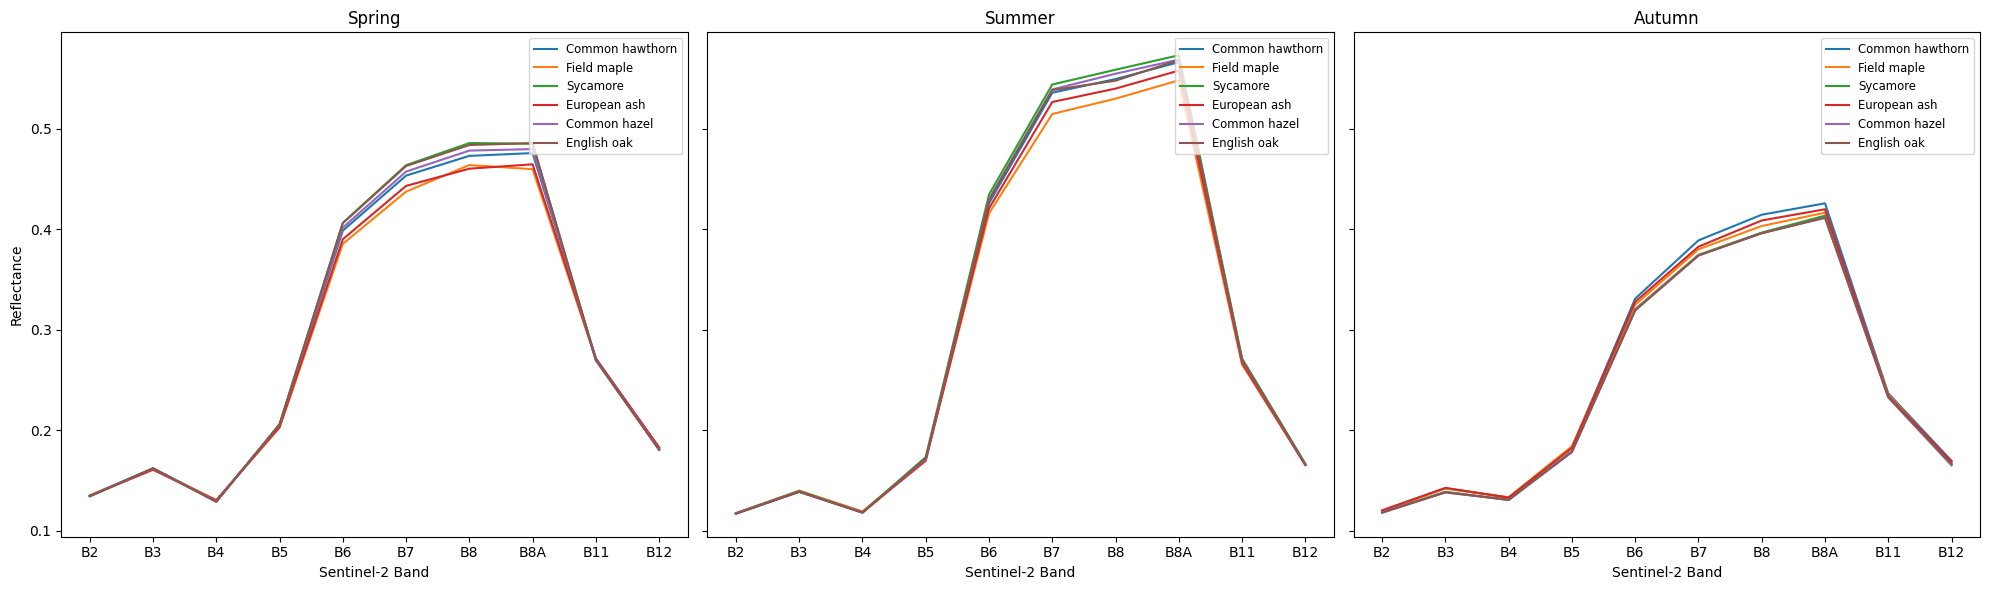

In [ ]:
#some crutial packages
import pandas as pd
import matplotlib.pyplot as plt

#Define seasons and Sentinel-2 bands
seasons = {
    'Spring': ('2022-04-01', '2022-05-31'),
    'Summer': ('2022-06-15', '2022-08-31'),
    'Autumn': ('2022-09-15', '2022-11-30')
}

bands = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']

# Clouds are our enemies, cloud masking function
def mask_s2(image):
    qa = image.select('QA60')
    cloud_mask = qa.bitwiseAnd(1 << 10).eq(0).And(qa.bitwiseAnd(1 << 11).eq(0))
    return image.updateMask(cloud_mask).divide(10000).select(bands)

# Storage for seasonal results
results = {}

# Loop over seasons
for season, (start, end) in seasons.items():
    s2 = ee.ImageCollection("COPERNICUS/S2_SR") \
        .filterDate(start, end) \
        .filterBounds(tree_points) \
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
        .map(mask_s2)

    # Median composite for the season
    composite = s2.median()

    # Sample spectral values at tree points
    sampled = composite.sampleRegions(
        collection=filtered_tree_points,
        properties=['common_nam'],
        scale=10,
        geometries=False
    )

    # Convert to pandas DataFrame without using ee_to_geopandas
    features = sampled.getInfo()['features']
    df = pd.DataFrame([
        {**f['properties']} for f in features
    ])

    results[season] = df

# Plot spectral signatures
classes = results['Spring']['common_nam'].unique()
fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for i, season in enumerate(seasons.keys()):
    df = results[season]
    ax = axs[i]

    for cls in classes:
        mean_vals = df[df['common_nam'] == cls][bands].mean()
        ax.plot(bands, mean_vals, label=cls)

    ax.set_title(season)
    ax.set_xlabel('Sentinel-2 Band')
    if i == 0:
        ax.set_ylabel('Reflectance')
    ax.legend(fontsize='small', loc='upper right')

plt.tight_layout()
plt.show()


##Detailed spectral signatures!
That is a bit crowded, let`s zoom to the red-edge bands!

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


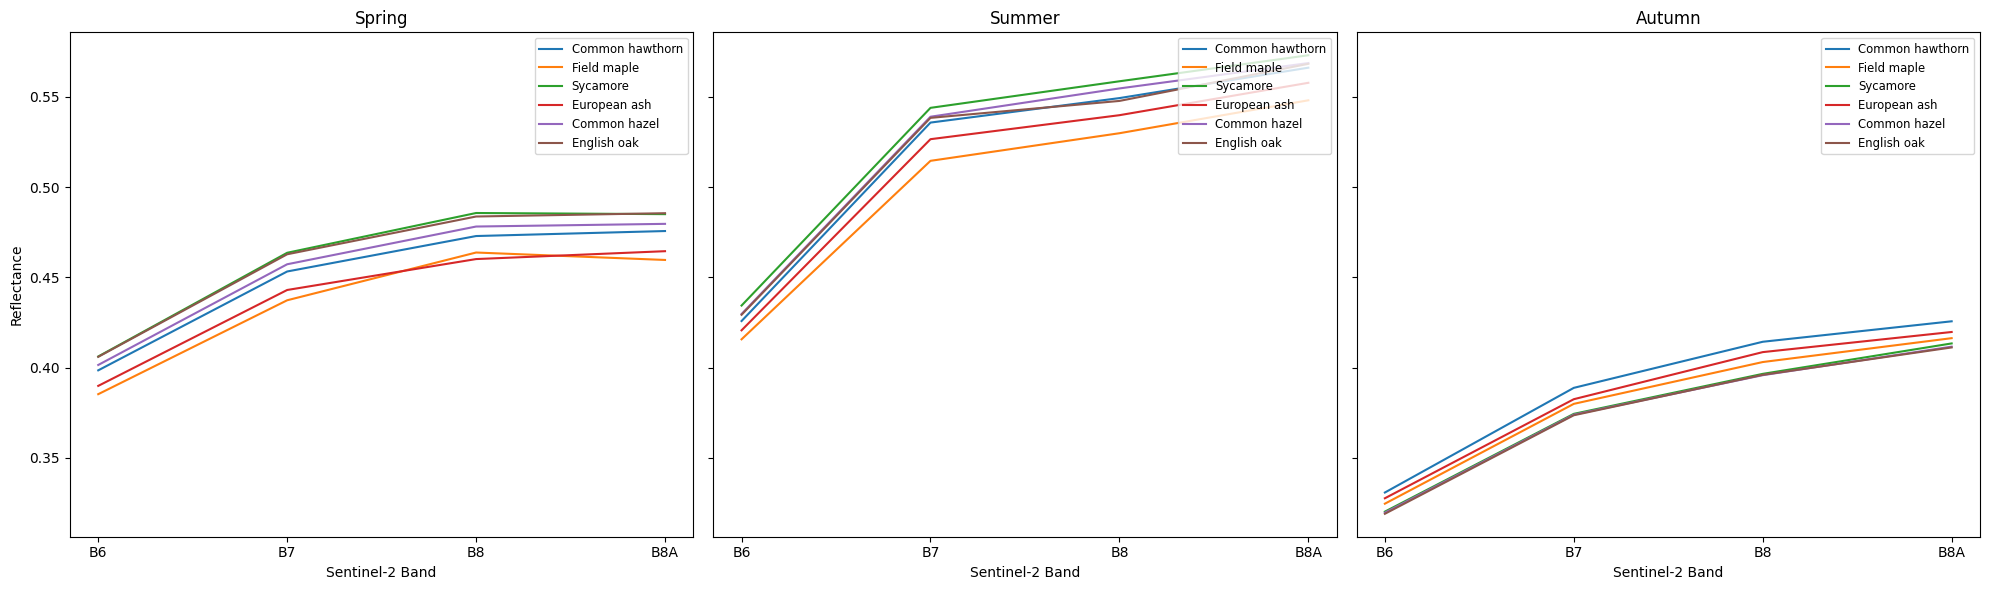

In [ ]:
#some crutial packages
import pandas as pd
import matplotlib.pyplot as plt

#Define seasons and Sentinel-2 bands
seasons = {
    'Spring': ('2022-04-01', '2022-05-31'),
    'Summer': ('2022-06-15', '2022-08-31'),
    'Autumn': ('2022-09-15', '2022-11-30')
}

bands = ['B6', 'B7', 'B8', 'B8A']

# Clouds are our enemies, cloud masking function
def mask_s2(image):
    qa = image.select('QA60')
    cloud_mask = qa.bitwiseAnd(1 << 10).eq(0).And(qa.bitwiseAnd(1 << 11).eq(0))
    return image.updateMask(cloud_mask).divide(10000).select(bands)

# Storage for seasonal results
results = {}

# Loop over seasons
for season, (start, end) in seasons.items():
    s2 = ee.ImageCollection("COPERNICUS/S2_SR") \
        .filterDate(start, end) \
        .filterBounds(tree_points) \
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
        .map(mask_s2)

    # Median composite for the season
    composite = s2.median()

    # Sample spectral values at tree points
    sampled = composite.sampleRegions(
        collection=filtered_tree_points,
        properties=['common_nam'],
        scale=10,
        geometries=False
    )

    # Convert to pandas DataFrame without using ee_to_geopandas
    features = sampled.getInfo()['features']
    df = pd.DataFrame([
        {**f['properties']} for f in features
    ])

    results[season] = df

# Plot spectral signatures
classes = results['Spring']['common_nam'].unique()
fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for i, season in enumerate(seasons.keys()):
    df = results[season]
    ax = axs[i]

    for cls in classes:
        mean_vals = df[df['common_nam'] == cls][bands].mean()
        ax.plot(bands, mean_vals, label=cls)

    ax.set_title(season)
    ax.set_xlabel('Sentinel-2 Band')
    if i == 0:
        ax.set_ylabel('Reflectance')
    ax.legend(fontsize='small', loc='upper right')

plt.tight_layout()
plt.show()


##NDVI
Let`s do the classic NDVI analysis. Temporal!

NDVI, or Normalized Difference Vegetation Index, is a widely used metric for assessing vegetation health and density using remote sensing data. It quantifies the difference between near-infrared and red light reflectance, providing insights into plant health and density. NDVI values range from -1 to +1, with higher values generally indicating denser and healthier vegetation.


The formula for NDVI is: (NIR - Red) / (NIR + Red), where NIR is near-infrared reflectance and Red is red light reflectance.
This calculation normalizes the data, making it easier to compare vegetation across different areas and time periods.


What it indicates:
- Values range from -1 to 1.
- Negative values (close to -1) generally indicate water bodies.
- Values close to zero (e.g., -0.1 to 0.1) represent barren areas like rock, sand, or snow.
- Low positive values (e.g., 0.2 to 0.4) typically signify shrub and grassland.
- High positive values (approaching 1) often indicate dense, healthy vegetation like forests.

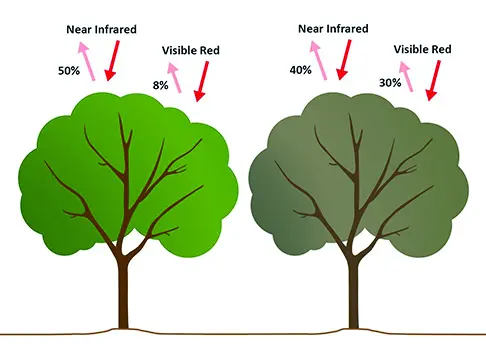

⚠️ Skipping Sep: Missing bands


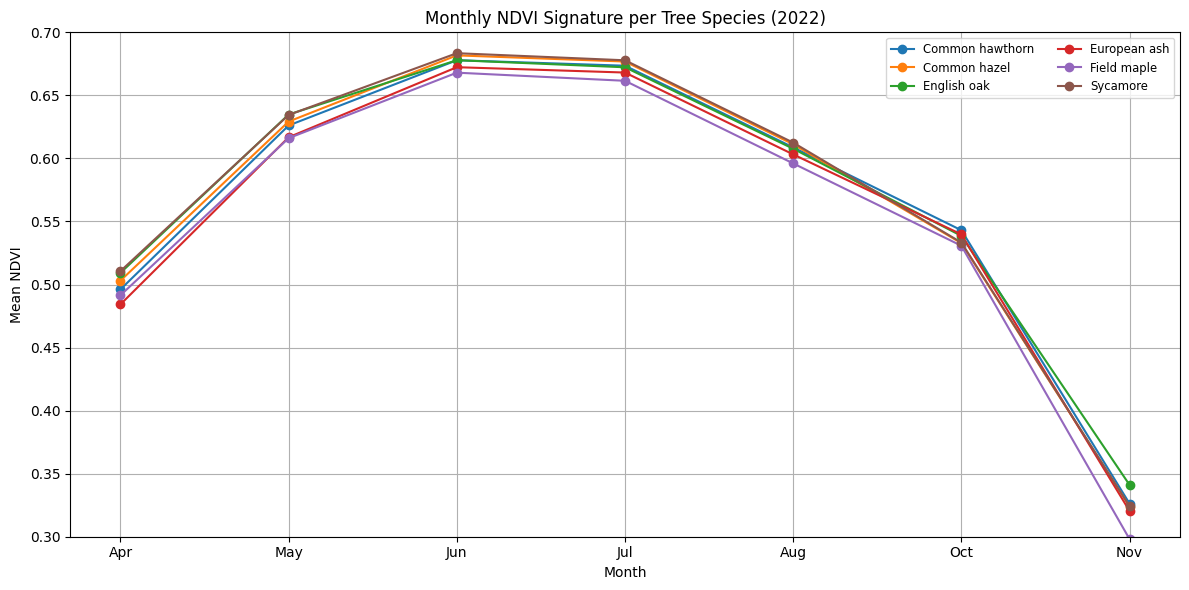

In [ ]:
# Define months and labels
months = ['04', '05', '06', '07', '08', '09', '10', '11']
year = '2022'
month_labels = ['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov']

# Cloud masking function
def mask_s2(image):
    qa = image.select('QA60')
    cloud_mask = qa.bitwiseAnd(1 << 10).eq(0).And(qa.bitwiseAnd(1 << 11).eq(0))
    return image.updateMask(cloud_mask).divide(10000)

# Storage for NDVI by month
ndvi_results = {}

# Loop through each month
for i, m in enumerate(months):
    start = f'{year}-{m}-01'
    end = f'{year}-{m}-28'  # safe end

    s2 = ee.ImageCollection("COPERNICUS/S2_SR") \
        .filterDate(start, end) \
        .filterBounds(filtered_tree_points) \
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
        .map(mask_s2)

    composite = s2.median()
    band_names = composite.bandNames().getInfo()

    # Ensure required bands exist
    if 'B4' in band_names and 'B8' in band_names:
        ndvi = composite.normalizedDifference(['B8', 'B4']).rename('NDVI')

        sampled = ndvi.sampleRegions(
            collection=filtered_tree_points,
            properties=['common_nam'],
            scale=10,
            geometries=False
        )

        features = sampled.getInfo()['features']
        df = pd.DataFrame([{**f['properties']} for f in features])

        # Mean NDVI per class
        grouped = df.groupby('common_nam')['NDVI'].mean()
        ndvi_results[month_labels[i]] = grouped
    else:
        print(f"⚠️ Skipping {month_labels[i]}: Missing bands")

# Build NDVI dataframe (rows = months, columns = classes)
ndvi_df = pd.DataFrame(ndvi_results).transpose()

# Plot all classes in one graph
plt.figure(figsize=(12, 6))
for col in ndvi_df.columns:
    plt.plot(ndvi_df.index, ndvi_df[col], marker='o', label=col)

plt.title('Monthly NDVI Signature per Tree Species (2022)')
plt.xlabel('Month')
plt.ylabel('Mean NDVI')
plt.ylim(0.3, 0.7)
plt.grid(True)
plt.legend(fontsize='small', ncol=2, loc='upper right')
plt.tight_layout()
plt.show()

Now let`s classify!

Pixel-based classification:
Assigns a class to each individual pixel based on its spectral characteristics.


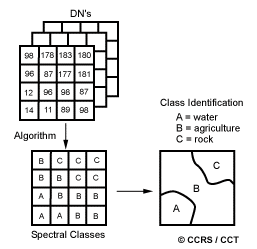

In [ ]:
# Define bands and months
bands = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
months = ['04', '05', '06', '07', '08', '10', '11']
year = '2022'

# Cloud masking function
def mask_s2(img):
    qa = img.select('QA60')
    cloud_mask = qa.bitwiseAnd(1 << 10).eq(0).And(qa.bitwiseAnd(1 << 11).eq(0))
    return img.updateMask(cloud_mask).divide(10000)

# Build monthly image stack with renamed bands and NDVI
image_stack = None
for m in months:
    start = f'{year}-{m}-01'
    end = f'{year}-{m}-28'

    img = ee.ImageCollection("COPERNICUS/S2_SR") \
        .filterDate(start, end) \
        .filterBounds(filtered_tree_points.geometry()) \
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
        .map(mask_s2) \
        .median()

    renamed = img.select(bands).rename([f"{b}_{m}" for b in bands])
    ndvi = img.normalizedDifference(['B8', 'B4']).rename(f'NDVI_{m}')
    full = renamed.addBands(ndvi)

    image_stack = image_stack.addBands(full) if image_stack else full

# Create buffer around each tree point (10 meters)
buffered_points = filtered_tree_points.map(lambda f: f.buffer(10))
buffered_area = buffered_points.geometry()

# Sample image at tree points and label classes
sampled = image_stack.sampleRegions(
    collection=filtered_tree_points,
    properties=['common_nam'],
    scale=10,
    geometries=False
)

# Map classes to numeric labels (client-side for display)
unique_names = filtered_tree_points.aggregate_array('common_nam').distinct().getInfo()
class_map = {name: i for i, name in enumerate(unique_names)}
print("✅ Class map:", class_map)

# Now convert to ee.Dictionary and apply labels server-side
ee_class_map = ee.Dictionary(class_map)

def set_label(feat):
    label = ee_class_map.get(feat.get('common_nam'))
    return feat.set('label', ee.Number(label))

training_data_labeled = sampled.map(set_label)


# Prepare features and split into training/testing
s2_features = [f"{b}_{m}" for b in bands for m in months] + [f"NDVI_{m}" for m in months]

training_data = training_data_labeled.randomColumn('random', seed=42)
train = training_data.filter(ee.Filter.lt('random', 0.8))
test = training_data.filter(ee.Filter.gte('random', 0.8))

# Train Random Forest classifier
classifier = ee.Classifier.smileRandomForest(numberOfTrees=100) \
    .train(features=train, classProperty='label', inputProperties=s2_features)

# Classify only the buffered area
classified_img = image_stack.classify(classifier).clip(buffered_area)

# Visualize results
palette = ['#1b9e77', '#d95f02', '#7570b3', '#e7298a', '#66a61e',
           '#e6ab02', '#a6761d', '#666666', '#1f78b4', '#b2df8a']

Map = geemap.Map()
Map.centerObject(filtered_tree_points, zoom=17)
Map.addLayer(classified_img, {"min": 0, "max": len(class_map)-1, "palette": palette}, "Classified Buffer")
Map.addLayer(filtered_tree_points, {}, "Tree Points")
Map

✅ Class map: {'Common hawthorn': 0, 'Field maple': 1, 'Sycamore': 2, 'European ash': 3, 'Common hazel': 4, 'English oak': 5}


Map(center=[51.776217398771294, -1.3372612108090889], controls=(WidgetControl(options=['position', 'transparen…

In [ ]:
# Classify the test set
test_classified = test.classify(classifier)

# Error matrix (confusion matrix)
conf_matrix = test_classified.errorMatrix('label', 'classification')
print('Confusion Matrix:')
print(conf_matrix.getInfo())

# Overall Accuracy
accuracy = conf_matrix.accuracy()
print('Overall Accuracy:', accuracy.getInfo())

# Optional: Kappa statistic (useful for unbalanced classes)
kappa = conf_matrix.kappa()
print('Kappa:', kappa.getInfo())


NameError: name 'test' is not defined